# Module 4 — Cohort Retention

**Platform:** REES46 Open CDP — anonymous multi-category e-commerce retailer, Kazakhstan / CIS market. 2,064,899 users with at least one purchase, grouped into 7 monthly acquisition cohorts (Oct 2019 – Apr 2020).

**Where this fits in the project:** Module 1 (Funnel Analysis) established that ~6% of sessions convert. Module 3 (RFM Segmentation) showed that a small "Champion" segment drives most revenue. This module asks a third, distinct question: once someone buys for the first time, do they come back? A cohort = all users whose *first-ever* purchase fell in the same calendar month. Each cohort is tracked forward to see what fraction is still active 1, 2, 3... months later.

**Business question:** Do customers come back month after month, and how fast does that drop off?

**Observation window caveat:** the dataset only runs Oct 2019 – Apr 2020 (7 months). The Oct 2019 cohort is the only one with a full 6-month look-back; the Apr 2020 cohort (the largest, at 320,535 users — likely COVID-driven) has **no observable retention at all**, since month 1 would fall in May 2020, outside the dataset. Cells beyond a cohort's observable window are `NaN`, not zero — a critical distinction enforced throughout this notebook (see `sql/04_cohort_retention.sql`, Query 1, long format).

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# Design tokens — dataviz palette.md (reference instance), same tokens used across the project's notebooks
C_SURFACE   = '#fcfcfb'
C_PRIMARY   = '#0b0b0b'
C_SECONDARY = '#52514e'
C_MUTED     = '#898781'
C_GRID      = '#e1e0d9'
C_AXIS      = '#c3c2b7'
C_S1        = '#2a78d6'   # blue — slot 1, primary series (avg retention curve)

# Sequential blue ramp (palette.md 100->700 steps) for the heatmap —
# lightest step anchored to the chart surface, per the skill's sequential convention.
SEQ_BLUE = LinearSegmentedColormap.from_list(
    'seq_blue',
    ['#fcfcfb', '#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95', '#0d366b']
)

plt.rcParams.update({
    'figure.facecolor':  C_SURFACE,
    'axes.facecolor':    C_SURFACE,
    'axes.edgecolor':    C_AXIS,
    'axes.linewidth':    0.8,
    'grid.color':        C_GRID,
    'grid.linewidth':    0.5,
    'text.color':        C_PRIMARY,
    'axes.labelcolor':   C_SECONDARY,
    'xtick.color':       C_MUTED,
    'ytick.color':       C_MUTED,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

print('Setup complete.')

Setup complete.


---
## 1 — Cohort Retention Heatmap

One row per acquisition cohort, one column per month since first purchase (M0–M6). Built from Query 1's **long format** — each cohort only has rows for the months it can actually observe, so pivoting leaves genuinely missing cells as `NaN` rather than fabricating zeros.

**Reading it:** blank/gray cells = outside that cohort's observation window (not "no retention" — the data simply doesn't exist yet). M0 is always 100% by definition (a cohort is 100% "active" in its own acquisition month) — it's capped at the top of the color scale so the scale has contrast to spare for the far more interesting M1–M6 range.

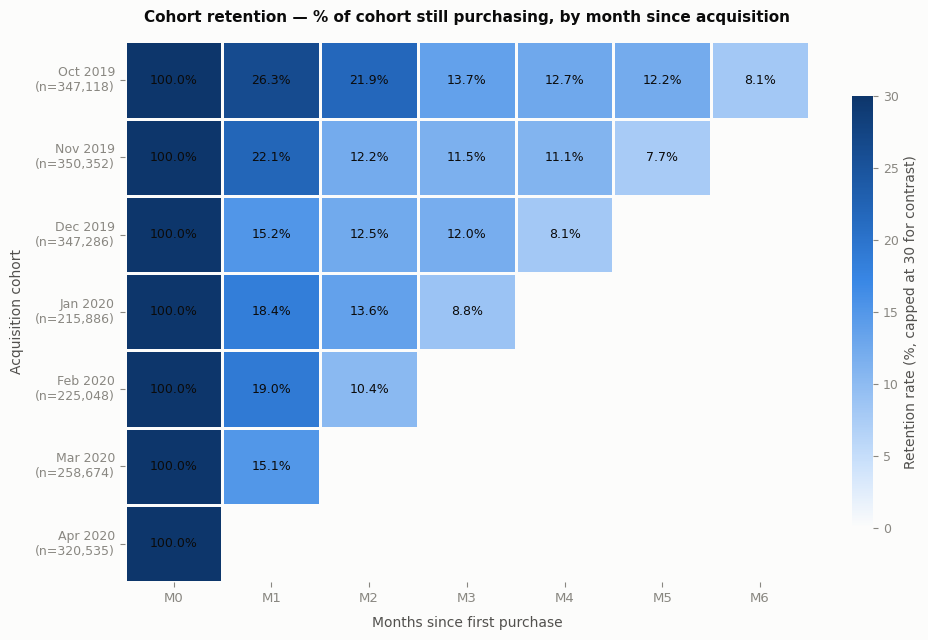

Saved: 04_fig1_cohort_heatmap.png

Blank cells = outside that cohort's observation window, not zero retention.
Apr 2020 (320,535 users, the largest cohort — likely COVID-driven signups)
has zero observable retention months. Whether they came back is unknown.


In [15]:
# Query 1 (long format) results, reconstructed as a dict per cohort —
# only observed (months_since_first, retention_rate_pct) pairs are included;
# offsets outside the observation window are simply absent (become NaN on pivot).
cohort_retention = {
    '2019-10': {0: 100.0, 1: 26.3, 2: 21.9, 3: 13.7, 4: 12.7, 5: 12.2, 6: 8.1},
    '2019-11': {0: 100.0, 1: 22.1, 2: 12.2, 3: 11.5, 4: 11.1, 5: 7.7},
    '2019-12': {0: 100.0, 1: 15.2, 2: 12.5, 3: 12.0, 4: 8.1},
    '2020-01': {0: 100.0, 1: 18.4, 2: 13.6, 3: 8.8},
    '2020-02': {0: 100.0, 1: 19.0, 2: 10.4},
    '2020-03': {0: 100.0, 1: 15.1},
    '2020-04': {0: 100.0},
}
cohort_sizes = {
    '2019-10': 347118, '2019-11': 350352, '2019-12': 347286,
    '2020-01': 215886, '2020-02': 225048, '2020-03': 258674, '2020-04': 320535,
}

cohort_months = list(cohort_retention.keys())
offsets = list(range(7))

df = pd.DataFrame(index=cohort_months, columns=offsets, dtype=float)
for month, row in cohort_retention.items():
    for offset, pct in row.items():
        df.loc[month, offset] = pct

annot_df = df.applymap(lambda v: f'{v:.1f}%' if pd.notna(v) else '')

month_names = {'2019-10': 'Oct 2019', '2019-11': 'Nov 2019', '2019-12': 'Dec 2019',
               '2020-01': 'Jan 2020', '2020-02': 'Feb 2020', '2020-03': 'Mar 2020',
               '2020-04': 'Apr 2020'}
row_labels = [f'{month_names[m]}\n(n={cohort_sizes[m]:,})' for m in cohort_months]

fig, ax = plt.subplots(figsize=(10, 6.5))
fig.patch.set_facecolor(C_SURFACE)

sns.heatmap(df, mask=df.isna(), annot=annot_df, fmt='', cmap=SEQ_BLUE,
            vmin=0, vmax=30, linewidths=2, linecolor=C_SURFACE,
            cbar_kws={'label': 'Retention rate (%, capped at 30 for contrast)', 'shrink': 0.8},
            annot_kws={'fontsize': 9, 'color': C_PRIMARY}, ax=ax)

ax.set_yticklabels(row_labels, rotation=0, fontsize=9)
ax.set_xticklabels([f'M{o}' for o in offsets], fontsize=9.5)
ax.set_xlabel('Months since first purchase', labelpad=8)
ax.set_ylabel('Acquisition cohort', labelpad=8)
ax.set_title('Cohort retention — % of cohort still purchasing, by month since acquisition',
             fontsize=11, fontweight='bold', pad=14, color=C_PRIMARY)

plt.tight_layout()
plt.savefig('04_fig1_cohort_heatmap.png', dpi=150, bbox_inches='tight', facecolor=C_SURFACE)
plt.show()
print('Saved: 04_fig1_cohort_heatmap.png')
print()
print('Blank cells = outside that cohort\'s observation window, not zero retention.')
print('Apr 2020 (320,535 users, the largest cohort — likely COVID-driven signups)')
print('has zero observable retention months. Whether they came back is unknown.')

---
## 2 — Average Retention Curve (the shape of the drop-off)

The heatmap shows cohort-by-cohort detail; this chart summarizes the *shape* everyone shares. Average retention rate at each month offset, with the min–max range across cohorts shown as a band. Fewer cohorts have data at higher offsets (M6 has only 1 cohort — Oct 2019 — so there's no band at that point).

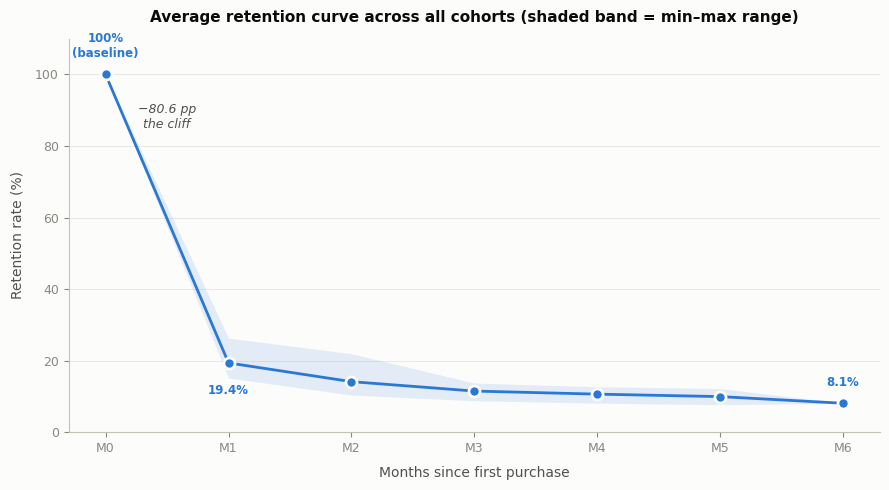

Saved: 04_fig2_retention_curve.png

The curve is almost entirely cliff-then-plateau: 100% -> 19.4% in one month,
then a slow decay (14.1% -> 11.5% -> 10.6% -> 9.9% -> 8.1%). Whoever survives
past M2 tends to keep coming back at a low, stable rate.


In [16]:
# Query 3 results — average / min / max retention by months_since_first
offsets_q3 = [0, 1, 2, 3, 4, 5, 6]
avg_ret    = [100.00, 19.36, 14.12, 11.49, 10.63, 9.94, 8.08]
min_ret    = [100.00, 15.13, 10.38,  8.79,  8.12, 7.67, 8.08]
max_ret    = [100.00, 26.30, 21.93, 13.73, 12.70, 12.21, 8.08]

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(C_SURFACE)

# Min-max band — area fill at ~12% opacity (marks spec: washes, never saturated blocks)
ax.fill_between(offsets_q3, min_ret, max_ret, color=C_S1, alpha=0.12, zorder=2, linewidth=0)

# Average line — 2px, round caps
ax.plot(offsets_q3, avg_ret, color=C_S1, linewidth=2, zorder=3,
        solid_capstyle='round', marker='o', markersize=8,
        markeredgecolor=C_SURFACE, markeredgewidth=2)

# Callout: the M0->M1 cliff — kept at the same x as the drop's midpoint (0.5),
# just lifted above the line instead of sliding sideways
ax.text(0.5, 88, '−80.6 pp\nthe cliff', fontsize=9, color=C_SECONDARY,
        ha='center', va='center', fontstyle='italic')

# Direct labels at start, the cliff, and end
ax.text(0, 100.00 + 4, '100%\n(baseline)', fontsize=8.5, ha='center', va='bottom',
        color=C_S1, fontweight='bold')
ax.text(1, 19.36 - 6, f'{19.36:.1f}%', fontsize=8.5, ha='center', va='top',
        color=C_S1, fontweight='bold')
ax.text(6, 8.08 + 4, f'{8.08:.1f}%', fontsize=8.5, ha='center', va='bottom',
        color=C_S1, fontweight='bold')

ax.set_xticks(offsets_q3)
ax.set_xticklabels([f'M{o}' for o in offsets_q3])
ax.set_xlabel('Months since first purchase', labelpad=8)
ax.set_ylabel('Retention rate (%)', labelpad=8)
ax.set_title('Average retention curve across all cohorts (shaded band = min–max range)',
             fontsize=11, fontweight='bold', pad=12, color=C_PRIMARY)
ax.set_ylim(0, 110)
ax.grid(axis='y', zorder=1)

plt.tight_layout()
plt.savefig('04_fig2_retention_curve.png', dpi=150, bbox_inches='tight', facecolor=C_SURFACE)
plt.show()
print('Saved: 04_fig2_retention_curve.png')
print()
print('The curve is almost entirely cliff-then-plateau: 100% -> 19.4% in one month,')
print('then a slow decay (14.1% -> 11.5% -> 10.6% -> 9.9% -> 8.1%). Whoever survives')
print('past M2 tends to keep coming back at a low, stable rate.')

---
## Summary of Findings

| Months since first purchase | Cohorts with data | Avg retention | Min | Max |
|---|---|---|---|---|
| M0 | 7 | 100.00% | 100.00% | 100.00% |
| M1 | 6 | 19.36% | 15.13% | 26.30% |
| M2 | 5 | 14.12% | 10.38% | 21.93% |
| M3 | 4 | 11.49% | 8.79% | 13.73% |
| M4 | 3 | 10.63% | 8.12% | 12.70% |
| M5 | 2 | 9.94% | 7.67% | 12.21% |
| M6 | 1 | 8.08% | 8.08% | 8.08% |

**1. The M0→M1 drop is the single biggest event in the entire retention curve.**  
Average retention falls from 100% to 19.4% in one month — roughly 4 in 5 first-time buyers never return the next month. This is the highest-leverage point in the customer lifecycle: improving M1 retention from 19% to 25% would add tens of thousands of returning buyers per cohort-month.

**2. After M2, the curve flattens into a slow, stable decay.**  
M2 (14.1%) → M3 (11.5%) → M4 (10.6%) → M5 (9.9%) → M6 (8.1%). Customers who survive past the M1 cliff become long-term, low-frequency repeaters rather than continuing to churn at the same rate.

**3. Oct 2019 has the best M1 retention (26.3%) of any cohort.**  
Likely the platform's pre-existing loyal customer base, already mid-cycle when the dataset window begins — not representative of true "new customer" behaviour.

**4. Dec 2019 has the worst M1 retention (15.2%).**  
A plausible post-holiday effect: customers acquired during November/December's promotional peak (see Module 5's category taxonomy findings for the same period) didn't convert into repeat habits.

**5. The Apr 2020 cohort (320,535 users, the largest in the dataset) has zero observable retention.**  
This is very likely the COVID-19 lockdown driving a wave of new e-commerce signups (Module 7 confirms the lockdown began March 16, 2020). Whether these users became repeat customers is the single biggest open question this dataset cannot answer — the observation window ends before their M1 would occur.

**6. Out-of-window cells are `NaN`, not zero — a data-handling detail that matters.**  
Early cohort-analysis attempts often plot missing future months as 0% retention, which visually (and wrongly) implies those cohorts failed. The heatmap in this notebook masks those cells instead, showing only what was actually observed.